# Imputation code to deal with NaN Values

## 1. Library and data import

In [2]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("C:/Users/atheb/Dropbox/Documents/polytechnique/S2/Introduction to Statistical Learning/Project/Final Merged and Imputed Datasets/Data_for_Imputation2.csv")
df

,ninsee,commune_area,building_Height_m,Area_Building_M2,Area_Impermeable_Mineral_M2,Area_Permeable_Bare_Soil,Area_Tree_Vegetation_M2,Area_Non_Tree_Vegetation_M2,Perc_Building,Perc_Impermeable_Mineral,...,Electricity_Electricity_2017,Electricity_Production_Total_2017,GHG_Tertiary_2021,GHG_Agriculture_2021,GHG_Transport_Other_2021,GHG_Trash_2021,GHG_Energy_2021,GHG_Industry_2021,GHG_Residential_2021,GHG_Road_2021
0,77001,0.769380,-1.398019,-0.150830,-0.022636,0.243103,0.745635,1.255976,0.008963,0.034766,...,-0.207849,0.301656,-0.469133,0.823046,-0.991252,-0.722624,-0.426473,-0.502415,-0.494996,0.806876
1,77002,1.537346,-1.096634,-0.265620,-0.143090,0.631781,1.557928,1.831692,0.004480,0.018160,...,-0.334670,-0.884042,-0.244969,1.537258,-0.991252,0.333015,-0.426473,0.017629,-0.465773,-0.109966
2,77003,0.676733,0.387041,-2.315410,-2.415923,-1.404051,-2.519238,-1.633742,0.000004,0.000071,...,-0.982110,-0.884042,-1.179044,0.867703,0.554323,-0.722624,-0.426473,-0.494395,-1.199031,-0.673520
3,77004,0.189218,0.013909,-0.691511,-0.663160,0.059223,-0.382590,1.134853,0.004614,0.020031,...,-0.857828,-0.884042,-1.251604,0.698503,-0.991252,-0.722624,2.108541,-0.403821,-1.284028,-1.381300
4,77005,0.897645,0.017766,0.057734,0.275024,0.752573,1.086515,0.733595,0.011695,0.046293,...,0.597833,0.699133,0.425919,-0.034784,1.042714,1.392226,-0.426473,0.161420,0.393012,-0.282603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1282,75116,1.257376,2.196604,2.562693,2.416512,-0.406608,1.257338,0.035729,0.170534,0.260193,...,2.210248,1.393770,1.915740,-1.464791,1.467633,2.035389,2.377302,1.731898,1.958067,1.760056
1283,75117,-0.336940,2.211614,2.254851,1.712548,-1.270914,-0.858785,-1.269906,0.377344,0.440266,...,2.210248,1.393770,1.915740,-1.464791,1.467633,2.035389,2.377302,1.731898,1.958067,1.760056
1284,75118,-0.323335,2.188574,2.160340,1.805661,-1.303985,-0.824714,-1.245769,0.342449,0.470533,...,2.210248,1.393770,1.915740,-1.464791,1.467633,2.035389,2.377302,1.731898,1.958067,1.760056
1285,75119,-0.156855,2.185504,2.178133,1.682271,-1.194000,-0.366603,-1.004501,0.309606,0.378130,...,2.210248,1.393770,1.915740,-1.464791,1.467633,2.035389,2.377302,1.731898,1.958067,1.760056


## 2. Data exploration

In [14]:
#Percentage of missing values for each predictor
nan_percentage_predictor = df.isnull().mean() * 100
print("Missing value report:")
print(nan_percentage_predictor.sort_values(ascending=False).to_string())

Missing value report:
Electricity_Production_Total_2017            15.850816
Gaz_Tertiary_2017                            13.986014
building_Height_m                            11.655012
Area_Building_M2                             11.188811
Area_Impermeable_Mineral_M2                  11.188811
Area_Permeable_Bare_Soil                     11.188811
Area_Tree_Vegetation_M2                      11.188811
Area_Non_Tree_Vegetation_M2                  11.188811
commune_area                                 11.188811
nb_sites_inconnu                              8.313908
conso_totale_inconnu                          8.313908
conso_totale_tertiaire                        4.428904
nb_sites_tertiaire                            4.428904
nb_sites_residentiel                          4.428904
conso_totale_residentiel                      4.428904
Median_Disposible_Income_2021                 1.320901
Housing_Occupied_Overcrowded                  0.155400
Housing_Occupied_Undercrowded              

In [15]:
#percentage of missing values for each communes
nan_percentage_row = (df.isnull().sum(axis=1) / df.shape[1]) * 100
display_df = df[['ninsee']].copy()
display_df['percentage_nan'] = nan_percentage_row
pd.set_option('display.max_rows', None)
print(display_df.sort_values(by='percentage_nan', ascending=False))

      ninsee  percentage_nan
1162   95282       64.864865
1022   93059       62.162162
331    77348       14.864865
188    77200       13.513514
53     77056       13.513514
495    77523       13.513514
258    77271       13.513514
19     77021       13.513514
338    77356       13.513514
445    77467       12.162162
195    77207       12.162162
451    77473       12.162162
186    77198       12.162162
67     77071       12.162162
68     77072       12.162162
1189   95387       12.162162
375    77395       12.162162
299    77313       12.162162
205    77218       12.162162
150    77158       12.162162
17     77019       12.162162
430    77452       12.162162
1248   95611       12.162162
8      77009       12.162162
173    77184       10.810811
371    77391       10.810811
223    77236       10.810811
367    77387       10.810811
296    77310       10.810811
1169   95304       10.810811
96     77102       10.810811
47     77050       10.810811
322    77338       10.810811
1251   95627  

## 3. Data cleaning before imputation

In [16]:
# drop communes with too many Nan observations
df2 = df.copy()
df2 = df2[~df2['ninsee'].isin([95282, 93059])]

#drop electricity_production_total_2017 (too many 0 and NaN values - no predictive power)
df2 = df2.drop(columns=['Electricity_Production_Total_2017'])

#Percentage of missing values for each predictor
nan_percentage_predictor = df2.isnull().mean() * 100
print("Missing value report:")
print(nan_percentage_predictor.sort_values(ascending=False).to_string())

Missing value report:
Gaz_Tertiary_2017                            13.852140
building_Height_m                            11.673152
commune_area                                 11.206226
Area_Building_M2                             11.206226
Area_Impermeable_Mineral_M2                  11.206226
Area_Permeable_Bare_Soil                     11.206226
Area_Tree_Vegetation_M2                      11.206226
Area_Non_Tree_Vegetation_M2                  11.206226
nb_sites_inconnu                              8.249027
conso_totale_inconnu                          8.249027
nb_sites_tertiaire                            4.435798
nb_sites_residentiel                          4.435798
conso_totale_residentiel                      4.435798
conso_totale_tertiaire                        4.435798
Median_Disposible_Income_2021                 1.167315
Number_Jobs                                   0.000000
Housing_Occupancy_Standard                    0.000000
Housing_Occupied_Overcrowded               

## 4. Imputation using KNN
Using 10 neighbours and weights inversely proportional to distance.
Land area columns are excluded. 

In [19]:
all_numeric_cols = df2.select_dtypes(include=['number']).columns.tolist()
#exclude ninsee
if 'ninsee' in all_numeric_cols:
    all_numeric_cols.remove('ninsee')

# Columns where we are imputing
cols_to_impute = [
    'Gaz_Tertiary_2017', 
    'building_Height_m', 
    'conso_totale_inconnu', 
    'nb_sites_residentiel', 
    'nb_sites_tertiaire', 
    'conso_totale_residentiel', 
    'conso_totale_tertiaire', 
    'Median_Disposible_Income_2021', 'nb_sites_inconnu']

#other columns where percentage of Nan values are 0
cols_complete = [
    c for c in all_numeric_cols 
    if df2[c].isnull().sum() == 0 and c not in cols_to_impute]

# Full list of columns used for KNN to find closest neighbours
cols_for_math = cols_to_impute + cols_complete

print(f"Columns used for KNN distance: {len(cols_for_math)}")
print(f"Specifically imputing: {cols_to_impute}")

# Initialize tools
scaler  = StandardScaler()
imputer = KNNImputer(n_neighbors=10, weights = 'distance')

#df_numeric_scaled = scaler.fit_transform(df2[cols_for_math])
df_numeric_imputed = imputer.fit_transform(df2[cols_for_math]) #imputes only on cols_to_impute although it uses all cols_for_math to find the closest neighbours
#df_numeric_final = scaler.inverse_transform(df_numeric_imputed) #inverse transform back to original units

# Putting the data back into df2
df2[cols_for_math] = df_numeric_imputed

print("\nRemaining NaN values per column:")
print(df2.isnull().sum())

print(f"\nOriginal shape: {df.shape}")
print(f"Clean shape:    {df2.shape}")

Columns used for KNN distance: 66
Specifically imputing: ['Gaz_Tertiary_2017', 'building_Height_m', 'conso_totale_inconnu', 'nb_sites_residentiel', 'nb_sites_tertiaire', 'conso_totale_residentiel', 'conso_totale_tertiaire', 'Median_Disposible_Income_2021', 'nb_sites_inconnu']

Remaining NaN values per column:
ninsee                                         0
commune_area                                 144
building_Height_m                              0
Area_Building_M2                             144
Area_Impermeable_Mineral_M2                  144
Area_Permeable_Bare_Soil                     144
Area_Tree_Vegetation_M2                      144
Area_Non_Tree_Vegetation_M2                  144
Perc_Building                                  0
Perc_Impermeable_Mineral                       0
Perc_Permeable_Bare_Soil                       0
Perc_Tree_Vegetation                           0
Perc_Non_Tree_Vegetation                       0
Land_Comp_Missing                              0
tra

In [20]:
#save to csv
df2.to_csv("Imputed_Normalised_KNN_data.csv", index=False)

In [21]:
df2.head()

,ninsee,commune_area,building_Height_m,Area_Building_M2,Area_Impermeable_Mineral_M2,Area_Permeable_Bare_Soil,Area_Tree_Vegetation_M2,Area_Non_Tree_Vegetation_M2,Perc_Building,Perc_Impermeable_Mineral,...,Eletricity_Total_2017,Electricity_Electricity_2017,GHG_Tertiary_2021,GHG_Agriculture_2021,GHG_Transport_Other_2021,GHG_Trash_2021,GHG_Energy_2021,GHG_Industry_2021,GHG_Residential_2021,GHG_Road_2021
0,77001,0.769380,-1.398019,-0.150830,-0.022636,0.243103,0.745635,1.255976,0.008963,0.034766,...,-0.441469,-0.207849,-0.469133,0.823046,-0.991252,-0.722624,-0.426473,-0.502415,-0.494996,0.806876
1,77002,1.537346,-1.096634,-0.265620,-0.143090,0.631781,1.557928,1.831692,0.004480,0.018160,...,-0.381098,-0.334670,-0.244969,1.537258,-0.991252,0.333015,-0.426473,0.017629,-0.465773,-0.109966
2,77003,0.676733,0.387041,-2.315410,-2.415923,-1.404051,-2.519238,-1.633742,0.000004,0.000071,...,-1.141084,-0.982110,-1.179044,0.867703,0.554323,-0.722624,-0.426473,-0.494395,-1.199031,-0.673520
3,77004,0.189218,0.013909,-0.691511,-0.663160,0.059223,-0.382590,1.134853,0.004614,0.020031,...,-1.028723,-0.857828,-1.251604,0.698503,-0.991252,-0.722624,2.108541,-0.403821,-1.284028,-1.381300
4,77005,0.897645,0.017766,0.057734,0.275024,0.752573,1.086515,0.733595,0.011695,0.046293,...,0.450200,0.597833,0.425919,-0.034784,1.042714,1.392226,-0.426473,0.161420,0.393012,-0.282603


## 5. Verifiying distributions

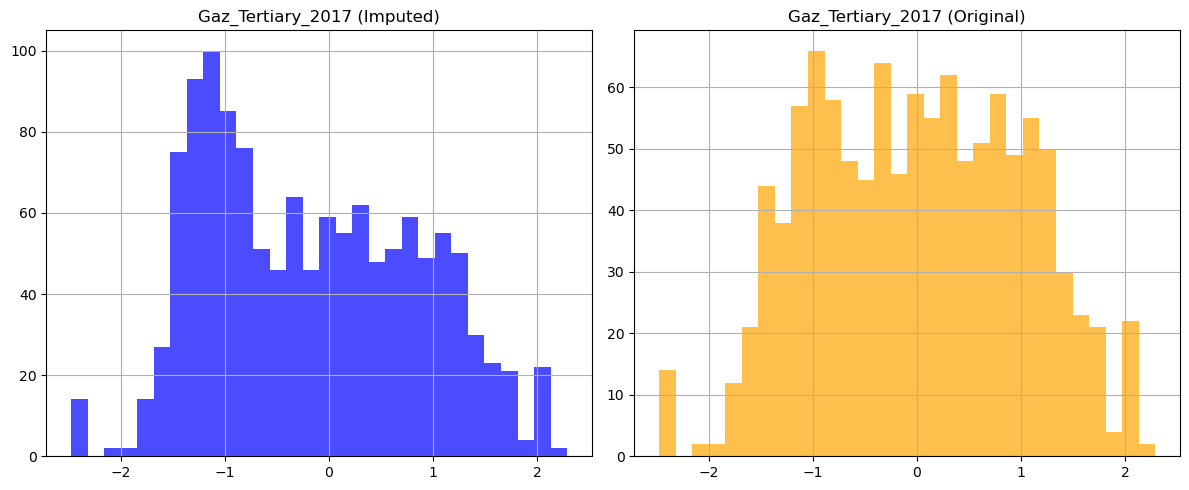

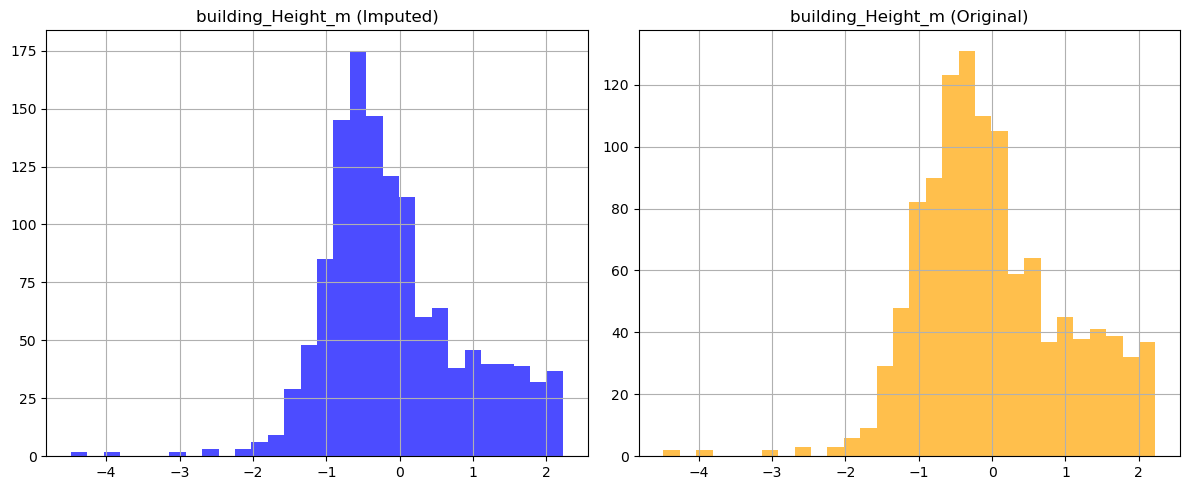

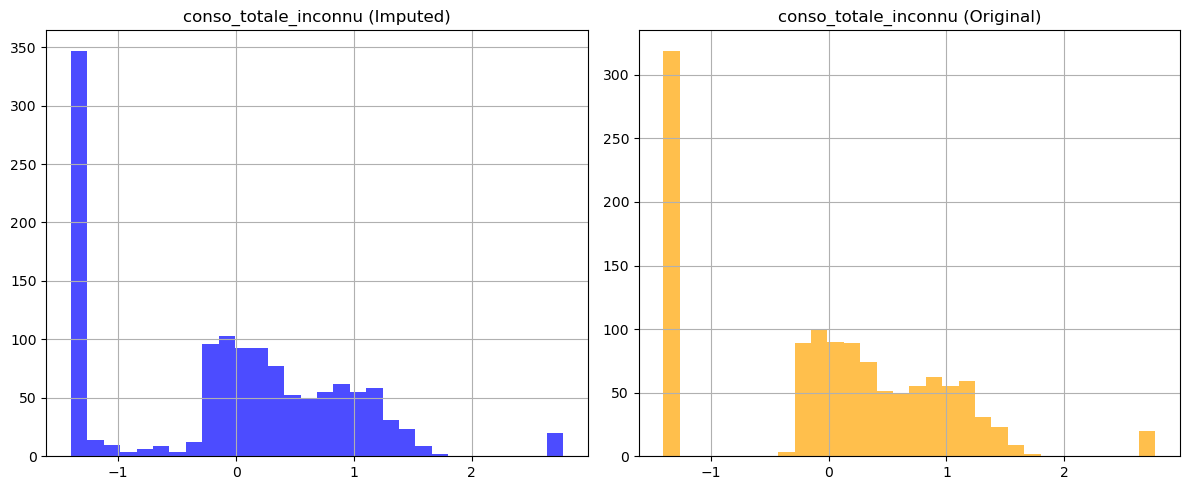

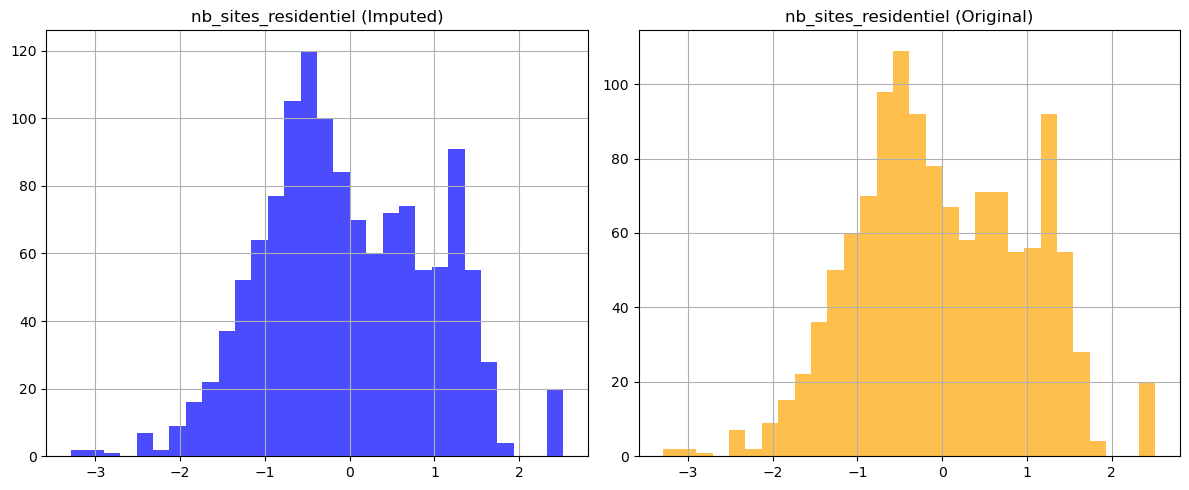

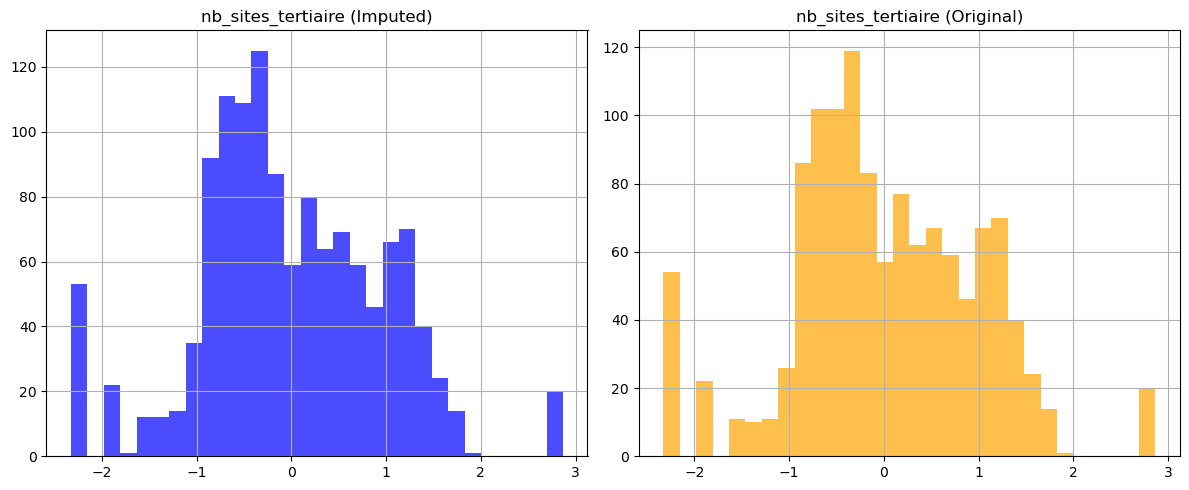

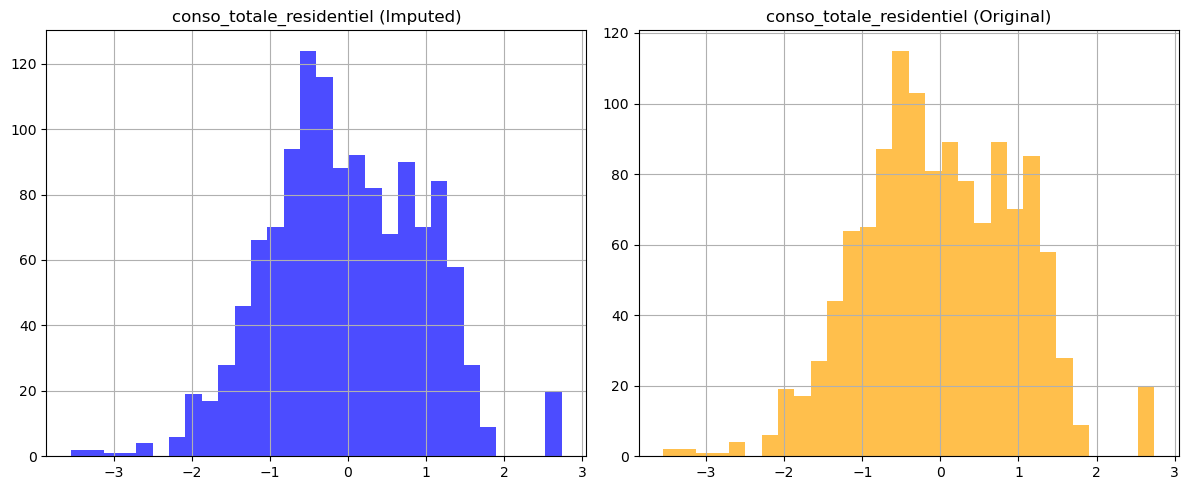

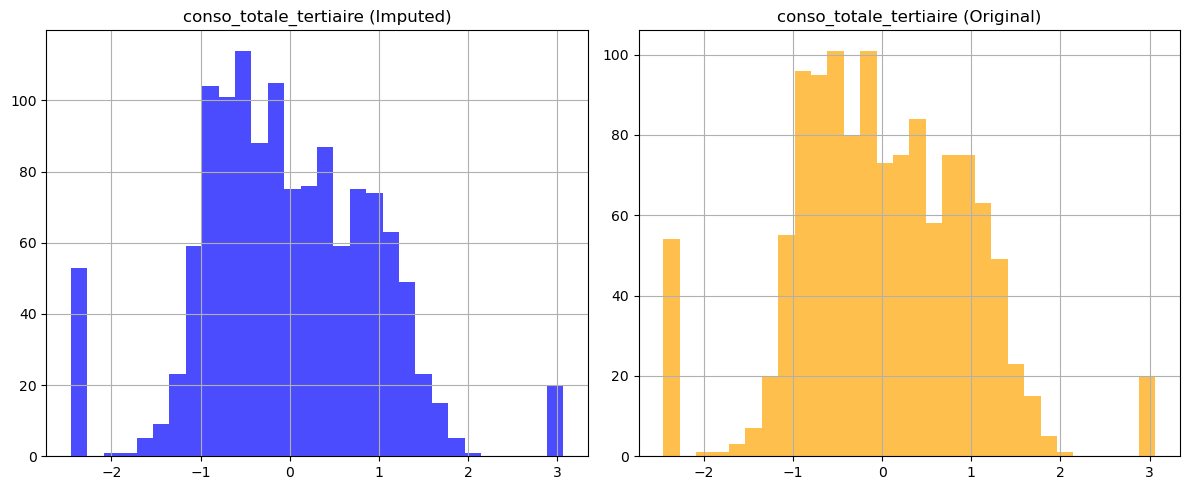

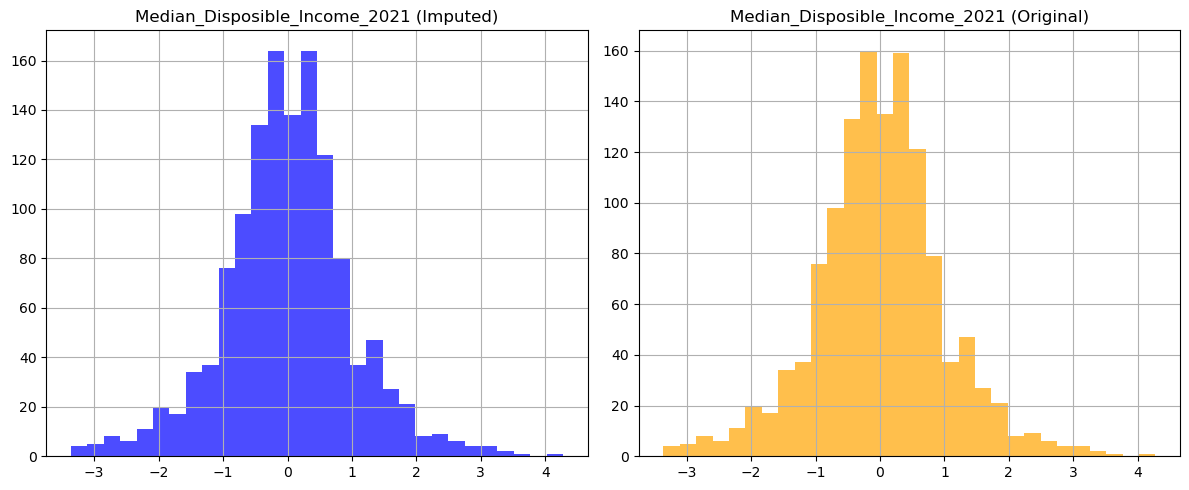

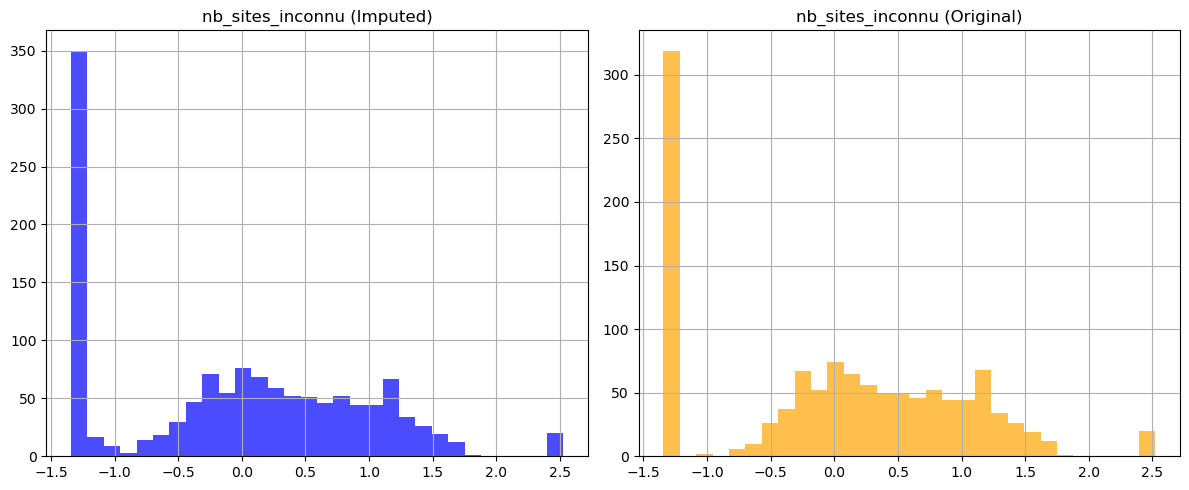

In [22]:
# give the imputed values a quick check by comparing distributions before and after imputation
import matplotlib.pyplot as plt
for col in cols_to_impute:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    df2[col].hist(bins=30, alpha=0.7, color='blue')
    plt.title(f"{col} (Imputed)")
    plt.subplot(1, 2, 2)
    df[col].hist(bins=30, alpha=0.7, color='orange')
    plt.title(f"{col} (Original)")
    plt.tight_layout()
    plt.show()